# Legume testing
## Import

In [11]:
import meep as mp
from meep import mpb
import meep.materials as materials
import legume
import legume.viz
import legume.backend as bd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as spo

import math

In [60]:
D=0.55
r=0.111
epsr=12

In [61]:
lattice = legume.Lattice("square")
phc = legume.PhotCryst(lattice)
phc.add_layer(d=D, eps_b=epsr)
phc.layers[-1].add_shape(legume.Circle(eps=1.0, r=r))
gme = legume.GuidedModeExp(phc, gmax=10)

Plane waves used in the expansion = 317.


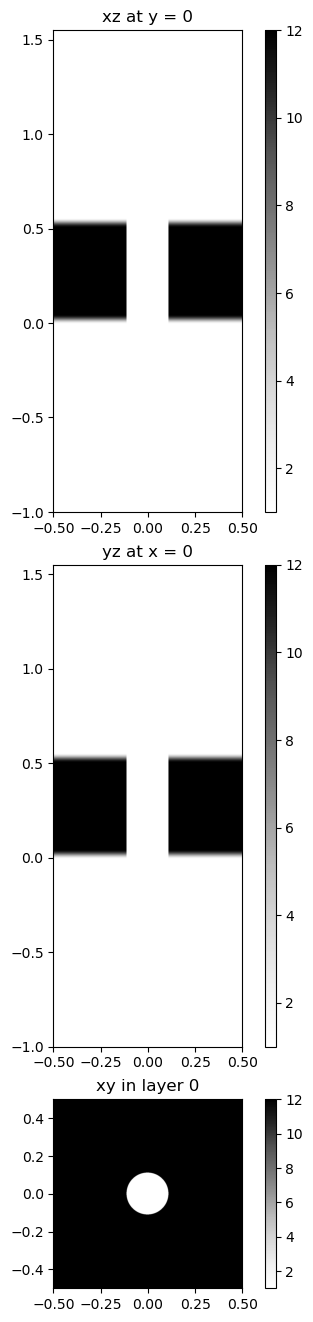

In [95]:
legume.viz.structure(phc, xz=True, yz=True, figsize=3, Ny=1000, Nx=1000)

In [91]:
path = lattice.bz_path([[0,0], [0.015,0], [0.0106, 0.0106], [0,0]], [40,1,40])
gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4],
        numeig=2, 
        eig_sigma = 0.47656,
        verbose = True)

212.547s total time for real part of frequencies in GuidedModeExp, of which
  11.765s (6%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  162.139s (76%) for matrix diagionalization using the 'eigh' solver
  38.577s (18%) for creating GME matrix
1.047s  total time for imaginary part of frequencies███████│ 82 of 82


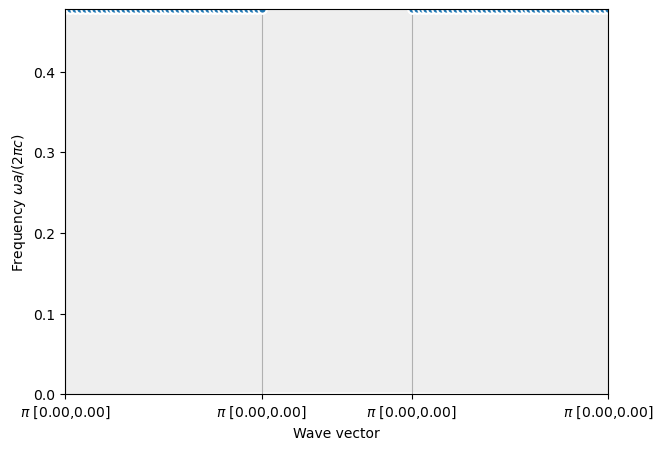

In [92]:
fig, ax = plt.subplots(1, figsize = (7, 5))
legume.viz.bands(gme, figsize=(5,5), k_units=True, Q=False, ax=ax, show_symmetry=True)
ax.set_xticks(path['k_indexes'])
ax.set_xticklabels(path['labels'])
ax.xaxis.grid('True')

In [93]:
gme.freqs

array([[0.47690126, 0.47690126],
       [0.47690126, 0.47690126],
       [0.47690125, 0.47690129],
       [0.47690124, 0.47690132],
       [0.47690123, 0.47690137],
       [0.47690122, 0.47690144],
       [0.4769012 , 0.47690152],
       [0.47690118, 0.47690161],
       [0.47690115, 0.47690172],
       [0.47690112, 0.47690184],
       [0.47690109, 0.47690198],
       [0.47690106, 0.47690213],
       [0.47690102, 0.4769023 ],
       [0.47690098, 0.47690248],
       [0.47690094, 0.47690267],
       [0.47690089, 0.47690288],
       [0.47690084, 0.4769031 ],
       [0.47690078, 0.47690334],
       [0.47690072, 0.47690359],
       [0.47690066, 0.47690386],
       [0.4769006 , 0.47690414],
       [0.47690053, 0.47690443],
       [0.47690046, 0.47690474],
       [0.47690039, 0.47690506],
       [0.47690031, 0.4769054 ],
       [0.47690023, 0.47690575],
       [0.47690015, 0.47690612],
       [0.47690006, 0.4769065 ],
       [0.47689997, 0.47690689],
       [0.47689987, 0.4769073 ],
       [0.

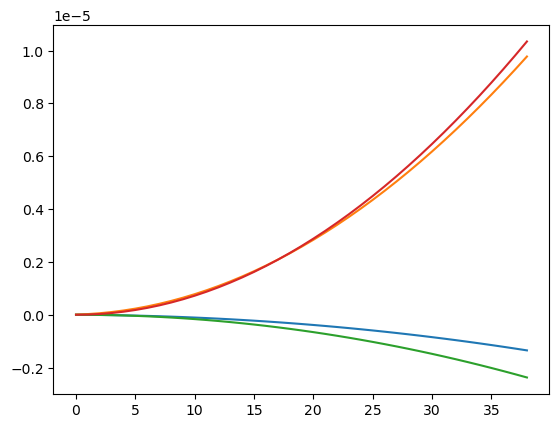

In [94]:
M=np.flip(gme.freqs[-40:-1],0)-gme.freqs[0][0]
X=gme.freqs[0:39]-gme.freqs[0][0]
plt.plot(M)
plt.plot(X)

In [99]:
gme.run(gmode_inds = [0,1,2,3,4],
        numeig=20,
        verbose = True)

2.019s total time for real part of frequencies in GuidedModeExp, of which
  0.037s (2%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  1.573s (78%) for matrix diagionalization using the 'eigh' solver
  0.409s (20%) for creating GME matrix
0.086s  total time for imaginary part of frequencies███████│ 1 of 1


In [102]:
test_freqs = gme.freqs[0]
test_freqs

array([3.93284283e-08, 8.20516501e-08, 3.35952451e-01, 3.36905116e-01,
       3.51032265e-01, 3.51032265e-01, 3.82747321e-01, 3.88662549e-01,
       3.88662549e-01, 3.94119836e-01, 4.52016751e-01, 4.54236278e-01,
       4.66972584e-01, 4.67738641e-01, 4.71917301e-01, 4.71917301e-01,
       4.76901257e-01, 4.76901257e-01, 4.82678810e-01, 4.95379231e-01])

In [ ]:
path = lattice.bz_path([[0,0], [0.015,0], [0.0106, 0.0106], [0,0]], [40,1,40])
band_locs = np.ndarray((20, 2, 40, 2))
for i in range(len(test_freqs)):
    gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3,4,5,6],
        numeig=2, 
        eig_sigma = test_freqs[i],
        verbose = False)
    band_locs[i][0]=gme.freqs[0:39]
    band_locs[i][1]=np.flip(gme.freqs[-1:-40], 0)